In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import simpson


custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

# **Flujos**

In [19]:
df_pb = pd.read_csv('Flujo_PB.csv',sep = ';')
df_md = pd.read_csv('Flujo_MD_tot.csv',sep = ';')

In [20]:
# Datos del paper de LX-ZEP
masa_PB = df_pb[df_pb.columns[0]] # Mev/c²
flujo_PB = df_pb[df_pb.columns[1]] # 1/(cm sr s)
masa_MD = df_md[df_md.columns[0]] # Mev/c²
flujo_MD = df_md[df_md.columns[1]] # 1/(cm sr s)



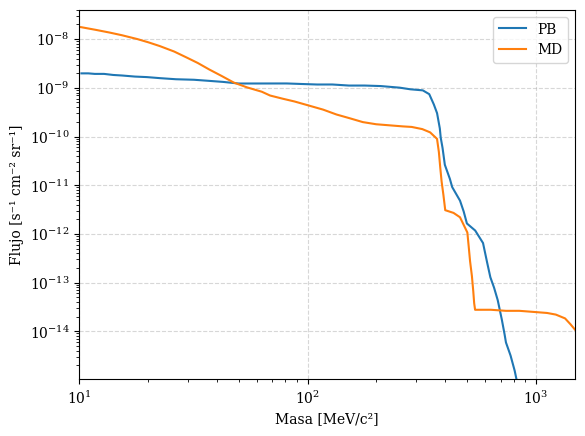

In [21]:
plt.plot(masa_PB, flujo_PB, '-', label='PB')
plt.plot(masa_MD, flujo_MD, '-', label='MD')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e1,np.max(masa_MD))
plt.ylim(np.min(flujo_PB),4e-8)
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Flujo [s⁻¹ cm⁻² sr⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [22]:
# Interpolación de los datos y cambio de unidades
masa_pb_ = df_pb[df_pb.columns[0]] # Mev/c²
flujo_pb_ =2*np.pi*df_pb[df_pb.columns[1]] # 1/(cm sr s) -> 1/(cm s)
masa_md_ = df_md[df_md.columns[0]] # Mev/c²
flujo_md_ =2*np.pi*df_md[df_md.columns[1]] # 1/(cm sr s) -> 1/(cm s)
orden = np.argsort(masa_pb_)
orden_md = np.argsort(masa_md_)
masa_pb_ = masa_pb_[orden]
flujo_pb_ = flujo_pb_[orden]
masa_md_ = masa_md_[orden_md]
flujo_md_ = flujo_md_[orden_md] 
# Intemasa_md = np.logspace(np.log10(np.min(masa_md)),np.log10(np.max(masa_md)),100)

masa_pb = np.logspace(np.log10(np.min(masa_pb_)),np.log10(np.max(masa_pb_)),100) # Mev/c²
masa_md = np.logspace(np.log10(np.min(masa_md_)),np.log10(np.max(masa_md_)),100) # Mev/c²
flujo_pb_interpolado = interp1d(masa_pb_, flujo_pb_, kind='linear', bounds_error=False, fill_value=0.0)
flujo_md_interpolado = interp1d(masa_md_, flujo_md_, kind='linear', bounds_error=False, fill_value=0.0)
flujo_pb = flujo_pb_interpolado(masa_pb) # 1/(cm s)
flujo_md = flujo_md_interpolado(masa_md) # 1/(cm s)

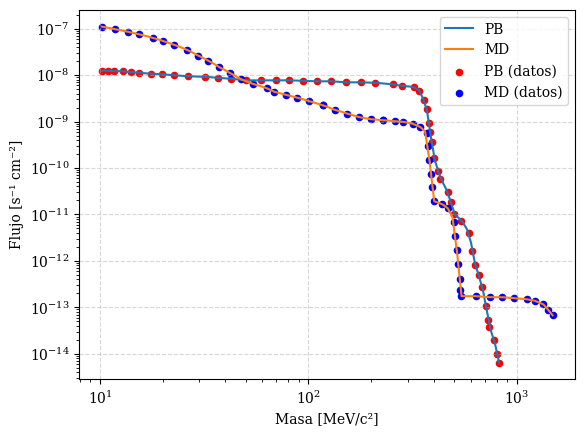

In [23]:
plt.plot(masa_pb, flujo_pb, '-', label='PB')
plt.plot(masa_md, flujo_md, '-', label='MD')
plt.scatter(masa_pb_, flujo_pb_, color='red', label='PB (datos)', s=20)
plt.scatter(masa_md_, flujo_md_, color='blue', label='MD (datos)', s=20)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Flujo [s⁻¹ cm⁻²]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [24]:
# Guardo el flujo interpolado
flujo_pb_df = pd.DataFrame({
    'Masa[MeV/c2]': masa_pb,
    'Flujo[s-1cm-2]': flujo_pb
}
)
flujo_md_df = pd.DataFrame({
    'Masa[MeV/c2]': masa_md,
    'Flujo[s-1cm-2]': flujo_md
}
)
flujo_pb_df.to_csv('Flujo_PB_interpolado.csv', index=False)
flujo_md_df.to_csv('Flujo_MD_interpolado.csv', index=False)

# **Sección eficaz**

In [25]:
df_se = pd.read_csv('Seccion_eficaz_DEr_mCP.csv',sep = ';')

In [ ]:
Er = np.array(df_se[df_se.columns[0]]) # eV
sigma_er_ = np.array(df_se[df_se.columns[1]]) # cm²/eV
orden = np.argsort(Er)
Er = Er[orden]
sigma_er_ = sigma_er_[orden]

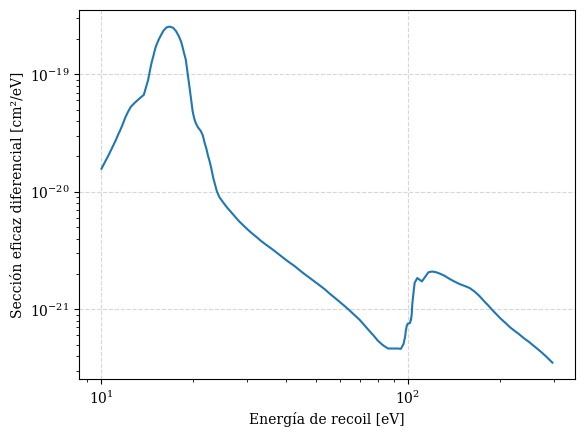

In [ ]:
plt.plot(Er, sigma_er_, '-', label='Sección eficaz')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Sección eficaz diferencial [cm²/eV]')
plt.grid(linestyle='--', alpha=0.5)

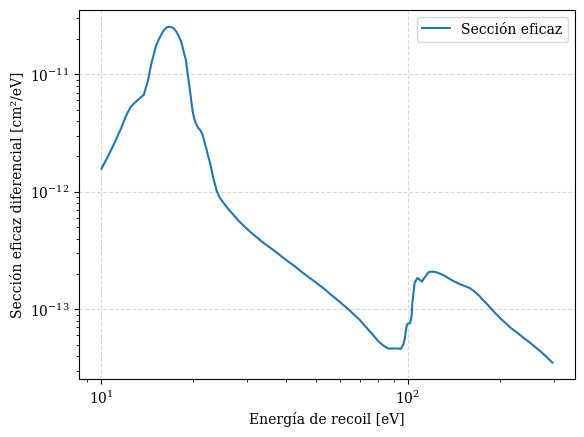

In [ ]:
sigma_er = np.array((df_se[df_se.columns[1]]))*(1e-2/1e-6)**2 # eps=1e-6--> 1e-2
plt.plot(Er, sigma_er, '-', label='Sección eficaz')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Sección eficaz diferencial [cm²/eV]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()

In [32]:
sec_eficaz_Si_mCP = pd.DataFrame({
    'Er[eV]': masa_pb,
    'Seccion_ef[cm2/eV]': flujo_pb
}
)

sec_eficaz_Si_mCP.to_csv('Seccion_eficaz_Si_mCP.csv', index=False)